<a href="https://colab.research.google.com/github/MukulVerma-ML/upskillCampus/blob/main/Agriculture_Crop_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df= pd.read_csv('datafile[1].csv')
df.columns=['Crop','State','Cost_A2','Cost_C2','Cost_Prediction','Yield']
print("Shape:",df.shape)
print(df.head(10))

Shape: (49, 6)
     Crop           State   Cost_A2   Cost_C2  Cost_Prediction  Yield
0   ARHAR   Uttar Pradesh   9794.05  23076.74          1941.55   9.83
1   ARHAR       Karnataka  10593.15  16528.68          2172.46   7.47
2   ARHAR         Gujarat  13468.82  19551.90          1898.30   9.59
3   ARHAR  Andhra Pradesh  17051.66  24171.65          3670.54   6.42
4   ARHAR     Maharashtra  17130.55  25270.26          2775.80   8.72
5  COTTON     Maharashtra  23711.44  33116.82          2539.47  12.69
6  COTTON          Punjab  29047.10  50828.83          2003.76  24.39
7  COTTON  Andhra Pradesh  29140.77  44756.72          2509.99  17.83
8  COTTON         Gujarat  29616.09  42070.44          2179.26  19.05
9  COTTON         Haryana  29918.97  44018.18          2127.35  19.90


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             49 non-null     object 
 1   State            49 non-null     object 
 2   Cost_A2          49 non-null     float64
 3   Cost_C2          49 non-null     float64
 4   Cost_Prediction  49 non-null     float64
 5   Yield            49 non-null     float64
dtypes: float64(4), object(2)
memory usage: 2.4+ KB


,0
Crop,0
State,0
Cost_A2,0
Cost_C2,0
Cost_Prediction,0
Yield,0


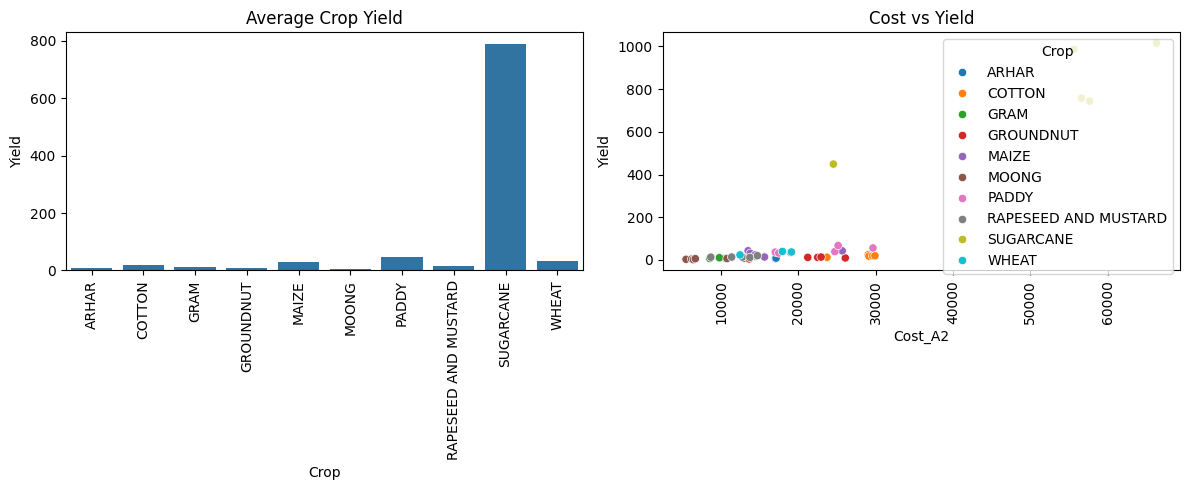

In [ ]:
# Understanding graph
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x='Crop',y='Yield',data=df,errorbar=None)
plt.xticks(rotation=90)
plt.title("Average Crop Yield")

plt.subplot(1,2,2)
sns.scatterplot(x='Cost_A2',y='Yield',data=df,hue='Crop')
plt.xticks(rotation=90)
plt.title("Cost vs Yield")
plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering
# Crop aur State ko number me badlo
# get_dummies = One Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Crop','State'], drop_first=True)

# 6. X aur y ALAG KARO
X = df_encoded.drop('Yield', axis=1) # Input features
y = df_encoded['Yield'] # Target

print("Total Features:", X.shape[1])

# 7. TRAIN TEST SPLIT
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Total Features: 24


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("\nStep 9: Training Model...")
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)
print("Training Done!")



Step 9: Training Model...
Training Done!


In [ ]:
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n========== MODEL PERFORMANCE ==========")
print(f"R2 Score: {r2:.3f}") # 1 ke kareeb = best
print(f"MAE: {mae:.3f}") # Kitni galti average
print(f"RMSE: {rmse:.3f}")


========== MODEL PERFORMANCE ==========
R2 Score: 0.925
MAE: 30.525
RMSE: 82.480



Top 10 Important Features:
                Feature  Importance
2       Cost_Prediction    0.398139
10       Crop_SUGARCANE    0.383217
1               Cost_C2    0.143485
0               Cost_A2    0.074416
22  State_Uttar Pradesh    0.000466
8            Crop_PADDY    0.000167
15      State_Karnataka    0.000025
19         State_Punjab    0.000023
6            Crop_MAIZE    0.000016
20      State_Rajasthan    0.000015


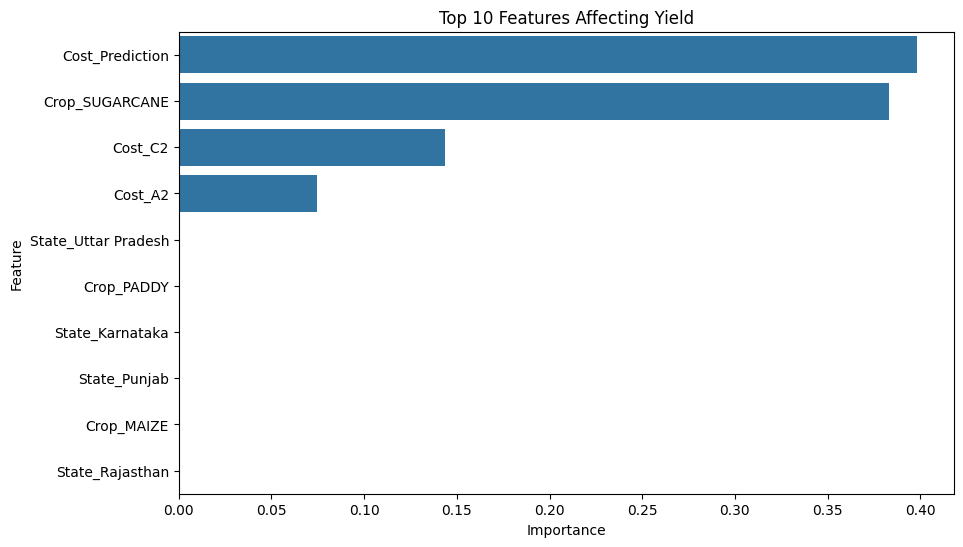

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Important Features:")
print(importance)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Top 10 Features Affecting Yield")
plt.show()

In [ ]:
# 12. SAVE MODEL
# Taaki baad me dubara train na karna pade
joblib.dump(model, 'yield_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns, 'feature_columns.pkl') # App me kaam aayega
print("\nModel, Scaler and Columns Saved Successfully!")



Model, Scaler and Columns Saved Successfully!


In [ ]:
# 13. TEST PREDICTION
# Ek example se check karo
print("\n========== TEST PREDICTION ==========")
sample = X_test_scaled[0].reshape(1,-1)
pred_yield = model.predict(sample)
print(f"Actual Yield: {y_test.iloc[0]:.2f} Qtl/Ha")
print(f"Predicted Yield: {pred_yield[0]:.2f} Qtl/Ha")


========== TEST PREDICTION ==========
Actual Yield: 8.05 Qtl/Ha
Predicted Yield: 8.70 Qtl/Ha
